##### 실행 환경 설정

In [1]:
try:
    # Google Drive를 Colab에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # 작업 경로 설정
    WORK_DIR = "/google_drive/Othercomputers/'내 컴퓨터'/sec08"
    print("\n[작업 폴더 목록]")
    %cd {WORK_DIR}
    !ls

    # 데이터셋 경로 설정
    DATASET_PATH = "/datasets/coco128-seg"
    import os
    if not os.path.exists(DATASET_PATH):
        !mkdir -p "/datasets"
        # coco128.zip 다운로드
        import urllib
        urllib.request.urlretrieve(
            "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128-seg.zip",
            "/datasets/coco128-seg.zip"
        )
        # coco128-seg.zip 압축 해제(압축 파일에 coco128-seg 폴더가 포함되어 있음)
        !unzip -qn "/datasets/coco128-seg.zip" -d "/datasets"
        # coco128-seg.zip 파일 삭제
        !rm "/datasets/coco128.zip"
    print("\n[데이터셋 폴더 목록]")
    print(DATASET_PATH)
    !ls {DATASET_PATH}
    print(DATASET_PATH + "/images")
    !ls {DATASET_PATH}/images
    print(DATASET_PATH + "/labels")
    !ls {DATASET_PATH}/labels
    print()

    # 한글 폰트 설치
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    !apt-get -qq install fonts-nanum
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    # 데이터셋 경로 설정
    DATASET_PATH = "../datasets/coco128-seg"

    # 로컬 dataset 폴더 접근 확인
    import os
    print("\n[데이터셋 폴더 목록]")
    print(f"{DATASET_PATH}")
    for dir in os.listdir(DATASET_PATH):
        print(dir, end='  ')

    # 한글 폰트 설정
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'Malgun Gothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False


[데이터셋 폴더 목록]
../datasets/coco128-seg
images  labels  LICENSE  README.txt  

##### 임포트

In [2]:
%%capture
!pip install -U ultralytics
from ultralytics import YOLO
from IPython.display import Image, display

##### YOLO 세그멘테이션 모델 구조

In [ ]:
# 사전 학습된 YOLO 세그멘테이션 모델 로드 (없으면 자동 다운로드)
model = YOLO("yolo11n-seg")  # yolo
# print(model)

# 모델 구조 요약
model.info()
# YOLO11n-seg summary: 203 layers, 2,876,848 parameters, 0 gradients, 9.900352 GFLOPs
#   - layers    : 모델을 구성하는 총 레이어 수
#   - parameters: 학습 가능한 가중치의 총 개수
#   - gradients : 현재 역전파에 사용 중인 그래디언트 수 (추론 모드에서는 0)
#   - GFLOPs    : 이미지 1장 추론 시 필요한 연산량 (100억 부동소수점 연산)
# 반환값: (layers, parameters, gradients, GFLOPs) 튜플


(203, 2876848, 0, 9.900352)

##### 사전 학습된 COCO 80개 클래스

In [4]:
# 모델이 인식 가능한 클래스 목록 (COCO 80개 클래스)
print(f"클래스 수: {len(model.names)}")
print()
for idx, name in model.names.items():
    print(f"  {idx:2d}: {name}")

클래스 수: 80

   0: person
   1: bicycle
   2: car
   3: motorcycle
   4: airplane
   5: bus
   6: train
   7: truck
   8: boat
   9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
  58: potted plant
  59: bed
  60: dining table
  61: toilet
  62: tv
  63: laptop
  64: mouse
  65: remote
  66: keyboard
  67: cell phone
  68: microwave
  69: oven
  70: toaster
  71: sink
  72: r

##### 추론해보기

d:\Work\ai\05-ai-model-development\projects\ai-model-development-v2\sec08/runs/segment/05/000000000532.jpg


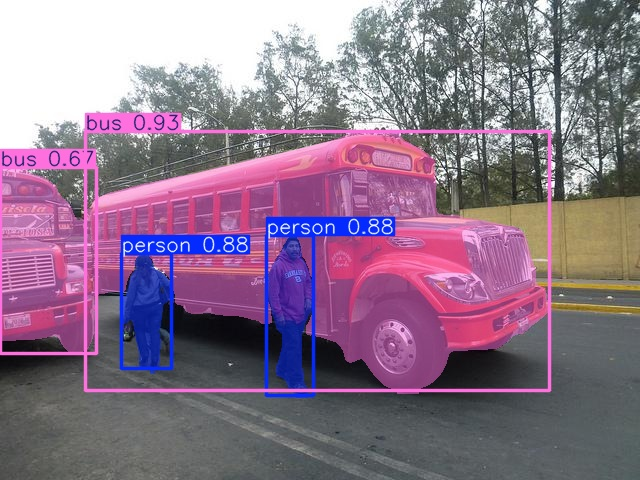

In [5]:
# 샘플 이미지 경로
image_path = f"{DATASET_PATH}/images/train2017/000000000532.jpg"

# 추론 (verbose=False → 추론 로그 출력 숨김)
results = model(
    image_path,
    save=True,
    name="05",         # runs/segment/05
    exist_ok=True,
    verbose=False)

# 결과 이미지 출력
result_image_path = f"{os.path.abspath(".")}/runs/segment/05/000000000532.jpg"
print(result_image_path)
display(Image(result_image_path))